# TS3: Análisis de Fourier: FFT, desparramo, interpolación y ventaneo.
### Gonzalo Constenla

# CHEQUEAR
[Nbviewer](https://nbviewer.org/github/GConstenlaP/AyPS/blob/main/TS3/TS3.ipynb)
[GitHub](https://github.com/GConstenlaP/AyPS/blob/main/TS3/TS3.ipynb)

### Introducción
En este trabajo se analiza el desparramo espectral (Leakage) causado por la DFT bajo distintas condiciones de frecuencia original de la señal.

Para la experimentación se genero una señal senoidal de frecuencia original $ f_0= k_0 \cdot \frac{fS}{N} = k_0 \cdot \Delta f$ y se varió el parámetro $k_0$ para estudiar el desparramo espectral en cada caso.

Además se pidió potencia unitaria ($P = 1W$) por lo cual se utilizó Amplitud $A = \sqrt{2}$ para la señal generada.

Luego, para estudiar el desparramo espectral se estudio la densidad espectral en decibelios y se verificó la identidad de Parseval.

#### Marco Teorico
La DFT representa una señal en el dominio de la frecuencia, mediante un conjunto de frecuencias discretas, llamadas bins de frecuencia. Cada bin esta asociado a un índice k.

$f_s$,  la frecuencia de muestreo, demarca el ancho de banda total que evalúa la DFT y **N** determina el numero de de puntos de evaluación.
De acá se deduce la separación entre un bin y el consecutivo que  se denomina resolucion frecuencial y se expresa:

$$\Delta f = \frac{f_s}{N} = \frac{1}{(NTs)} $$

Donde $T_s$ es el periodo de muestro.

El numero de bin, o indice de frecuencia **k** identifica cada una de las frecuencias discretas donde la DFT evalúa la señal. La frecuencia asociada a un bin puede calcularse como:

$$f_k = k \cdot \Delta f$$ Para k= 0, 1, 2 ..., N-1

##### **Enventanado** o *Data windowing*

En el procesamiento digital de las señales, al tomar una señal $x[n]$ y muestrarla N veces, equivale matemáticamente a multiplicar la señal original por una ventana rectangular $w[n]$:

$$x'[n] = x[n] \cdot w[n]$$

con:

$w[n] = 1 $ si $0 \le n \le N-1$.

$w[n] = 0 $ en otro caso

Por esto decimos que de no aplicar una ventana específica, estamos **implicitamente aplicando una ventana rectangular.**

En el dominio frecuencial: el espectro de la ventana rectangular $w[n]$ es una funcion periódica que llamamos sinc discreta y tambien es conocida como *Kernel de Dirichlet*:
$$\vert{}W(\theta)\vert{} = \left\vert{} \frac{\sin\left(\theta \frac{N}{2}\right)}{\sin\left(\frac{\theta}{2}\right)} \right\vert{}$$

donde $\theta $ es la frecuencia digital angular y se define: $\theta = 2\pi \frac{f}{f_s}$ (rad/muestra). 

Por lo que el Kernel de dirichlet expresado en frecuencia en hertz es:

$$\vert{}W(f)\vert{} = \left\vert{} \frac{\sin\left(2\pi \frac{f}{f_s} \cdot \frac{N}{2}\right)}{\sin\left(2\pi \frac{f}{f_s} \cdot \frac{1}{2}\right)} \right\vert{} = \left\vert{} \frac{\sin\left(\pi N \frac{f}{f_s}\right)}{\sin\left(\pi \frac{f}{f_s}\right)} \right\vert{} = \left\vert{} \frac{\sin\left(\pi \frac{f}{\Delta f}\right)}{\sin\left(\frac{\pi}{N} \frac{f}{\Delta f}\right)} \right\vert{}$$

Y por propiedad de la transformada de Fourier: multiplicar en un dominio, es convolucionar en el otro. Y el espectro de la senoidal sabemos que es una delta de Dirac centrada en la frecuencia original de la señal y por lo tanto el resultado de la transformada de Fourier es convolucionar la delta de la senoidal con la sinc de la ventana.

$$X(f) = \mathcal{F}\{x[n]\} * W(f)$$

$$X(f) = \delta(f - f_0) * W(f) = W(f - f_0)$$

Y si queremos tomar muestras discretas, la DFT equivale a:
$$X[k] = \left. X(f) \right\vert{}_{f = k \Delta f} = W(k \Delta f - f_0)$$


de esta forma el espectro de la sinusoidal se ve afectado por la ventana y la energía que estaba concentrada en la delta se desparrama en un lóbulo principal de ancho $2\Delta f$  y otros secundarios de ancho $\Delta f$

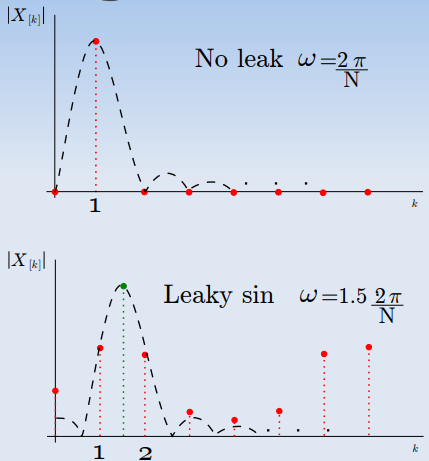

Como se ve en la imagen, dependiendo de la $ f_0$ de la señal original, podemos tener distintos casos:

1. Si es multiplo entero de la resolución espectral $f_0 = k_0 \cdot \Delta f$: el lóbulo principal de la sinc coincide con el $k_0$, el bin de la frecuencia original de la señal, lo que causa que la DFT evalúe la frecuencia en el máximo de amplitud. Y los demás bins discretos ($k \neq k_0$) coinciden con los ceros de la sinc, por lo que no se obtienen mas muestras espectrales con amplitud.

2. Si no es multiplo entero $f_0 \neq k_0 \cdot \Delta f$): La frecuencia original $f_0$ no coincide con ningun bin de frecuencia, y esta se encuentre entre 2 bins, entonces La DFT evaluará en frecuencias distintas del máximo, y se espera obtener mas de una muestra espectral con amplitud para el lóbulo principal. Y ademas los bins consecutivos de la DFT no coincidiran con ceros de la sinc, entonces los lobulos secundarios también proyectaran muestras espectrales con amplitud no nula.


Para estudiar y comparar la energía de la señal en dominio del tiempo y en el dominio frecuencial usaré la **Identidad de Parseval** (Introducida en la TS1), la cual establece la conservación de la energía entre el dominio temporal y frecuencial:$$\sum_{n=0}^{N-1} \vert{}x[n]\vert{}^2 = \frac{1}{N} \sum_{k=0}^{N-1} \vert{}X[k]\vert{}^2$$

Y la potencia media a partir de Parseval:

$$
P_{\text{media}}
=
\frac{1}{N}
\sum_{n=0}^{N-1}
|x[n]|^2
=
\frac{1}{N^2}
\sum_{k=0}^{N-1}
|X[k]|^2
$$


### Desarrollo
La señal fue generada con **N** = 1000 y $f_s = 1000$. Entonces la resolución espectral es de $\Delta_f = 1hz$
Los parámetros k_0 evualuados fueron 
1. $k_0 =\frac{N}{4}$
2. $k_0 =\frac{N}{4} + 0,25$
3. $k_0 =\frac{N}{4} + 0,5$

Por lo que las frecuencias de las señales eran
1. $ f_0 = 250hz$
2. $ f_0 = 250,25hz$
3. $ f_0 = 250,5hz$

la frecuencia de la señal f0 es : 250.0
la frecuencia de la señal f2 es : 250.25
la frecuencia de la señal f2 es : 250.5


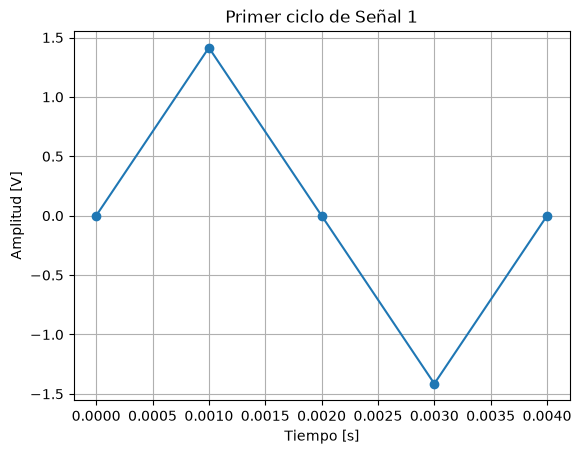

In [2]:

import numpy as np
import matplotlib.pyplot as plt
import scipy
# %% definiciones

N = 1000
fs = 1000
n = np.arange(N)
t = n / fs

delta_f = fs / N  # resolución espectral en hz = 1
#1 f0 = k0∗fS/N   =  k0.Δf

# %% funciones
def mi_funcion_sen(vmax=np.sqrt(2), dc=0, ff=1, ph=0, nn=N, fs=fs):
    tt = np.arange(nn) / fs
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx



def graficar_primer_ciclo(t, x, f, titulo):
    #implemento redondeo hacia arriba copn np.ceil
    muestras_por_ciclo = int(np.ceil(fs / f)) #muestras que componen un ciclo
    plt.figure()
    plt.plot(t[:muestras_por_ciclo + 1], x[:muestras_por_ciclo + 1],'o-')
    plt.title(titulo)
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud [V]')
    plt.grid()
    plt.show()

# %% mi script
#Graficar las tres densidades espectrales de potencia (PDS's) y discutir cuál es el efecto de dicha desintonía en el espectro visualizado.

# %% 1 k0= n/4

k0 = N/4
k1 = N/4 + 0.25
k2 = N/4 + 0.5

f0 = k0 * (fs/N)
f1 = k1 * (fs/N)
f2 = k2 * (fs/N)

t0, x0 = mi_funcion_sen(dc=0, ff=f0, ph=0, nn=N, fs=fs)
t1, x1 = mi_funcion_sen(dc=0, ff=f1, ph=0, nn=N, fs=fs)
t2, x2 = mi_funcion_sen(dc=0, ff=f2, ph=0, nn=N, fs=fs)
print("la frecuencia de la señal f0 es :", f0)
print("la frecuencia de la señal f2 es :", f1)
print("la frecuencia de la señal f2 es :", f2)
graficar_primer_ciclo(t0, x0, f0, 'Primer ciclo de Señal 1')

#graficar_primer_ciclo(t1, x1, f1, 'Primer ciclo de Señal 2')
#graficar_primer_ciclo(t2, x2, f2, 'Primer ciclo de Señal 3')

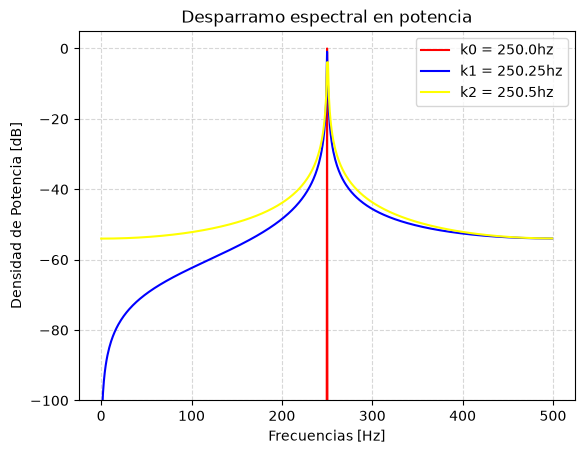

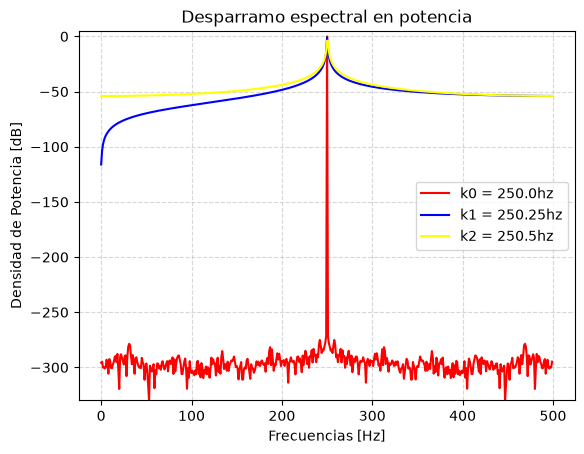

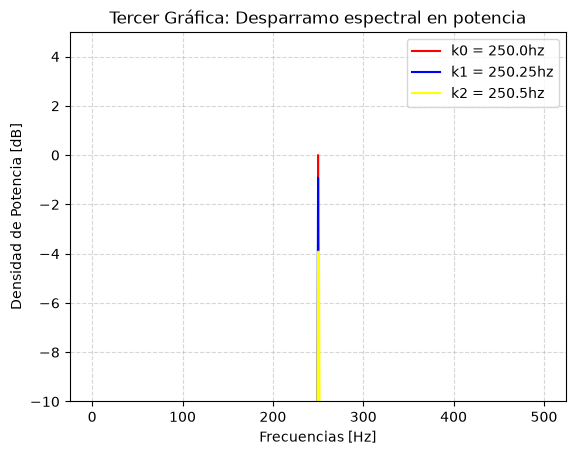

In [6]:
# %% f02

# Calculo de Potencia:
# modulo_fft_X   = np.abs(scipy.fft.fft(X)[:N//2]) / N
# Max1 = np.max(modulo_fft_X)
# PSD_X   = (modulo_fft_X /Max1)**2
# PSD_X_db   = 10 * np.log10(PSD_X)

fft_0 =np.abs( scipy.fft.fft(x0)[:N//2])/N
Max1 = np.max(fft_0 )
PSD_X0   = (fft_0/Max1)**2
PSD_X0_db   = 10 * np.log10(PSD_X0)

fft_1 =np.abs( scipy.fft.fft(x1)[:N//2])/N
PSD_X1   = (fft_1/Max1)**2
PSD_X1_db   = 10 * np.log10(PSD_X1)

fft_2 =np.abs( scipy.fft.fft(x2)[:N//2])/N
PSD_X2   = (fft_2/Max1)**2
PSD_X2_db   = 10 * np.log10(PSD_X2)

frecuencias = np.arange(0, fs/2, fs/N)

plt.figure()
plt.plot(frecuencias, PSD_X0_db, color= 'red', label  = f'k0 = {k0}hz')
plt.plot(frecuencias, PSD_X1_db, color= 'blue', label  = f'k1 = {k1}hz')
plt.plot(frecuencias, PSD_X2_db, color= 'yellow', label  = f'k2 = {k2}hz')

plt.title('Desparramo espectral en potencia')
plt.xlabel("Frecuencias [Hz]")
plt.ylabel("Densidad de Potencia [dB]")
plt.grid()
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(-100, 5)
plt.legend(loc='best')
plt.show()


plt.figure()
plt.plot(frecuencias, PSD_X0_db, color= 'red', label  = f'k0 = {k0}hz')
plt.plot(frecuencias, PSD_X1_db, color= 'blue', label  = f'k1 = {k1}hz')
plt.plot(frecuencias, PSD_X2_db, color= 'yellow', label  = f'k2 = {k2}hz')

plt.title('Desparramo espectral en potencia')
plt.xlabel("Frecuencias [Hz]")
plt.ylabel("Densidad de Potencia [dB]")
plt.grid()
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(-330, 5)
plt.legend(loc='best')
plt.show()


plt.figure()
plt.plot(frecuencias, PSD_X0_db, color= 'red', label  = f'k0 = {k0}hz')
plt.plot(frecuencias, PSD_X1_db, color= 'blue', label  = f'k1 = {k1}hz')
plt.plot(frecuencias, PSD_X2_db, color= 'yellow', label  = f'k2 = {k2}hz')

plt.title('Tercer Gráfica: Desparramo espectral en potencia')
plt.xlabel("Frecuencias [Hz]")
plt.ylabel("Densidad de Potencia [dB]")
plt.grid()
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(-10, 5)
plt.legend(loc='best')
plt.show()

En las gráficas se puede apreciar que por un lado la señal roja de frecuencia 250hz, casi no hay desparramo espectral y la potencia se concentra en el bin K0 = 250hz.

Para las otras señales, amarilla y azul, cuyas frecuencias solo difieran de una pequeña fracción, con frecuencias $f_0 = 250,25hz$ y $f_0 = 250,5hz$ se produce desparramo espectral considerable aumentando al aproximarse a sus respectivos $f_0$ y esto coincide con lo esperado ya que su frecuencia original de señal no es multiplo entero de las frecuencia de los bins que depende de la frecuencia de muestreo $f_s$

Con densidad espectral de 1hz, ambas frecuencias caen entre el bin k = 250: de 250hz y el bin k = 251: de 251 hz.

Entonces en ambas señales (Azul y amarilla), en el rango en frecuencia [249, 251]hz, que corresponde al Lobulo principal de la sinc,
La dft evalúa en frecuencias que no coinciden con el maximo de las señales y esto se puede ver en la tercer Gráfica, donde se ve que la señal roja marca un maximo de potencia mayor a la azul, y la azul mayor a la amarilla, ya que esta ultima todavia se encuentra mas lejos del bin.

Ademas en las señales Azul y amarilla, la dft esta evaluando frecuencias donde caen lobulos secundarios, lo que muestra el efecto del desparramo espectral y devuelve resultados de optencia en frecuencias distintas de la frecuencia de la señal original de entrada.


### Parte B: Verificación de potencia unitaria
En este apartado, usaré la identidad de Parseval para demostrar que a pesar de que los gráficos hayan devuelto distinta distribución de potencia con máximos distintos
La potencia de las señales es la misma


### Parte C: Zero Padding